## Getting Dtw distance matrix

In [ ]:
!pip install dtaidistance


In [23]:
#import neccessary data
import numpy as np
import pickle
from dtaidistance import clustering, dtw_ndim
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


try:
    with open('operationList.pkl', 'rb') as f:
        operations = pickle.load(f)
except:
    print("Error")


In [24]:
distMatrix = dtw_ndim.distance_matrix(operations, ndim=57)


In [25]:
np.shape(distMatrix)

(24, 24)

## Running Tsne

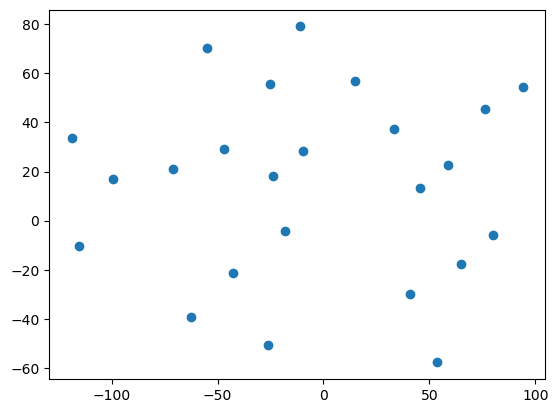

In [31]:
embedded = TSNE(n_components=2, metric='precomputed', random_state=42, init='random', perplexity = 5).fit_transform(distMatrix)


# plot
plt.scatter(embedded[:, 0], embedded[:, 1])
plt.show()

Data isnt showing any clusters clearly but since we dont procedure labels its hard to really tell whats going on

## Hiearchical clustering

In [27]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage 

condensedDist = squareform(distMatrix) #flattening squared distMatrix for hiearchical clustering
x = linkage(condensedDist, method='complete') #linkage matrix

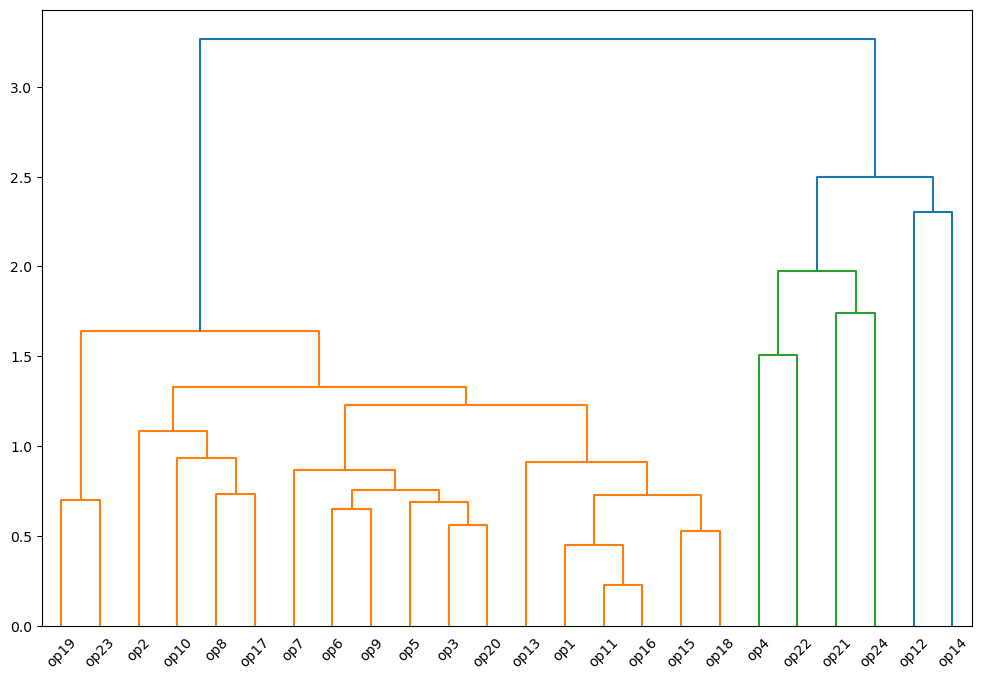

In [28]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

opLabels = [f"op{i}" for i in range(1, 25)]

plt.figure(figsize=(12, 8))

dendrogram(x, labels = opLabels)
plt.show()

Observations:
- 3 main clusters: 
    - Seems to be clustered based on op length (in terms of frames)
    - Orange cluster far larger containing 19/24 operations, suggesting that green and blue clusters may be outliers
    - Blue frame len avg: 101 , Green frame len avg: 49,   compared to global avg of 24 frames

Will try dtw again with sakoe chiba band to see if that changes results

In [41]:
x_Chiba1 = clustering.LinkageTree(dtw_ndim.distance_matrix_fast, 
                                dists_options={"ndim": 57, "window": 5}).fit(operations) #tight constraint

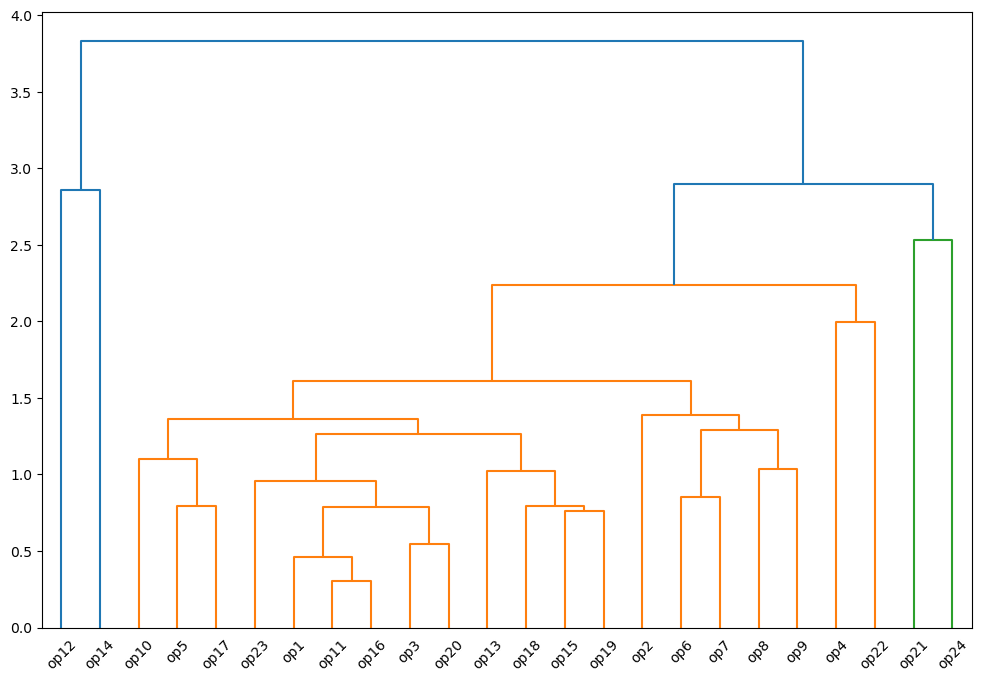

In [ ]:
plt.figure(figsize=(12, 8))

dendrogram(x_Chiba1, labels = opLabels)
plt.show()

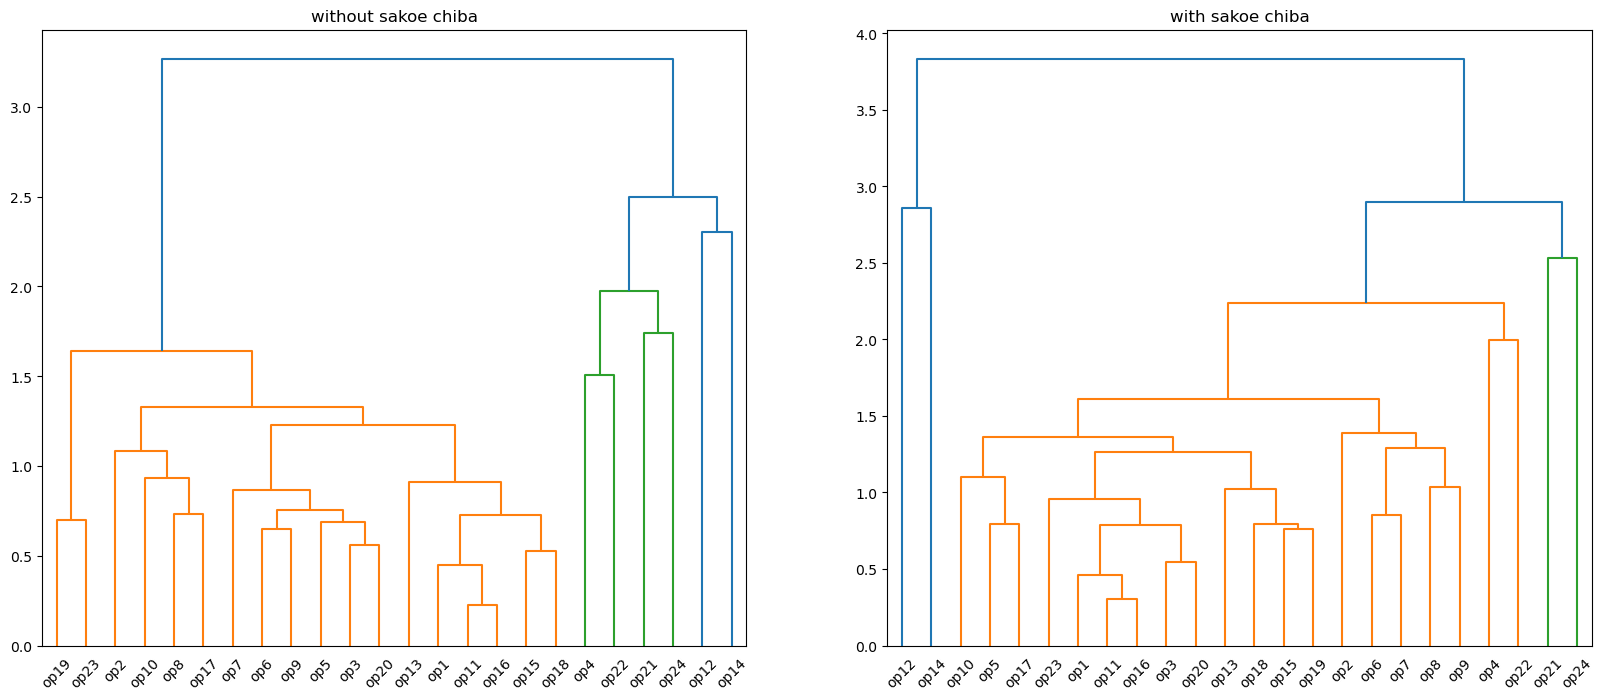

In [48]:
##plotting both side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
dendrogram(x,  ax = ax1, labels = opLabels)
dendrogram(x_Chiba1, ax = ax2, labels = opLabels)

ax1.set_title("without sakoe chiba")
ax2.set_title("with sakoe chiba")

plt.show()



Adding sakoe chiba didnt help much due to the vast difference between largest and smallest frame